# Brain Tumor Detection (VGG16 Binary Classification)

Versión adaptada al dataset de Kaggle:

- yes = tumor presente
- no = tumor ausente

Incluye:
- Train / Validation / Test
- VGG16 Transfer Learning
- Accuracy, Precision, Recall y F1
- Matriz de confusión
- Curvas de entrenamiento
- model.save()
- load_model()

In [7]:
# pip install scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Model, load_model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


## Hyperparameters

In [32]:

IMG_SIZE = 256 # 256 = 256x256
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 0.0001 # Static max, as in https://arxiv.org/pdf/1512.03385, page 4
DROPOUT = 0.5 # https://arxiv.org/pdf/1207.0580, page 2

ACTIVATION = "sigmoid" # Single class
LOSS_METHOD = "binary_crossentropy" # Expects a single neuron (sigmoid)

TRAIN_DIR = "dataset__readytouse/train"
VAL_DIR = "dataset__readytouse/validation"
TEST_DIR = "dataset__readytouse/test"


## Dataset Structure
```text
dataset/
├── train/
│   ├── yes/
│   └── no/
├── validation/
│   ├── yes/
│   └── no/
└── test/
    ├── yes/
    └── no/
```

En TensorFlow/Keras, la asignación de etiquetas para conjuntos de datos estructurados en carpetas locales no requiere un etiquetado manual en código. Funciones como `image_dataset_from_directory()` automatizan este proceso mediante **inferencia topológica**.

```text
dataset/
├── train/
│   ├── yes/  --> Clase 1 (Alfabéticamente)
│   └── no/   --> Clase 0 

```

In [28]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
    shuffle=False # Solo en test queremos evitar el shuffle, para debuggear mejor.
)

classes = train_ds.class_names # Binary
num_classes = len(classes)
print(classes)
print(num_classes)

Found 153 files belonging to 2 classes.
Found 50 files belonging to 2 classes.
Found 50 files belonging to 2 classes.
['no', 'yes']
2


## Build a VGG16 Architecture

Source: https://arxiv.org/pdf/1512.03385, page 4

For the classification head, the two 4096-unit dense layers were removed, as the task involved only two output classes (N=256), making such a high-capacity head unnecessarily complex.

The network is organized into five convolutional blocks followed by a classifier:

| Block       | Architecture                                |
|-------------|---------------------------------------------|
| **VGG16 Layer 1** | Conv(64) → Conv(64) → MaxPool               |
| **VGG16 Layer 2** | Conv(128) → Conv(128) → MaxPool             |
| **VGG16 Layer 3**| Conv(256) → Conv(256) → Conv(256) → MaxPool |
| **VGG16 Layer 4** | Conv(512) → Conv(512) → Conv(512) → MaxPool |
| **VGG16 Layer 5** | Conv(512) → Conv(512) → Conv(512) → MaxPool |
| **Head (manual)** | Flatten → Dense(1000) → Softmax |

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Input,
    Dropout,
    BatchNormalization, 
)
from tensorflow.keras.applications.vgg16 import VGG16
model = Sequential()

# Transferencia de aprendizaje, dataset muy pequeño
vgg16_layer = VGG16(weights="imagenet", include_top=False)
vgg16_layer.trainable = False
model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(vgg16_layer)

# Cabeza manual
model.add(Flatten())
# model.add(Dense(4096, activation="relu"))
# model.add(Dense(4096, activation="relu"))
model.add(Dense(1000, activation="relu"))
model.add(Dropout(DROPOUT))
model.add(Dense(1, activation=ACTIVATION)) # Classes reduced to 1 (yes,no)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1000)           │    32,769,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │         1,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,484,689 (181.14 MB)

 Trainable params: 32,770,001 (125.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Compile

In [34]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=LOSS_METHOD,
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

## Train

In [35]:

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "checkpoints/{epoch:02d}.keras",
        save_freq=len(train_ds) * 3, # every 3 epochs, better slicing
        monitor="val_accuracy"
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "checkpoints/best_model.keras",
        save_best_only=True,
        monitor="val_accuracy"
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds, 
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.6928 - loss: 6.8083 - precision_1: 0.7447 - recall_1: 0.7527 - val_accuracy: 0.8600 - val_loss: 1.9209 - val_precision_1: 0.8529 - val_recall_1: 0.9355
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.8954 - loss: 3.1825 - precision_1: 0.9326 - recall_1: 0.8925 - val_accuracy: 0.8000 - val_loss: 4.2224 - val_precision_1: 0.7561 - val_recall_1: 1.0000
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9085 - loss: 2.1484 - precision_1: 0.9072 - recall_1: 0.9462 - val_accuracy: 0.9000 - val_loss: 0.7743 - val_precision_1: 0.9643 - val_recall_1: 0.8710
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9542 - loss: 0.5091 - precision_1: 0.9479 - recall_1: 0.9785 - val_accuracy: 0.8600 - val_loss: 3.6131 - val_precision_1: 1.0000 - val_recall_1: 0.7742
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 137s 7s/step - accuracy: 0.9673 - loss: 0.8908 - precision_1: 0.9783 - recall_1: 0.9677 - val

## Training Curves

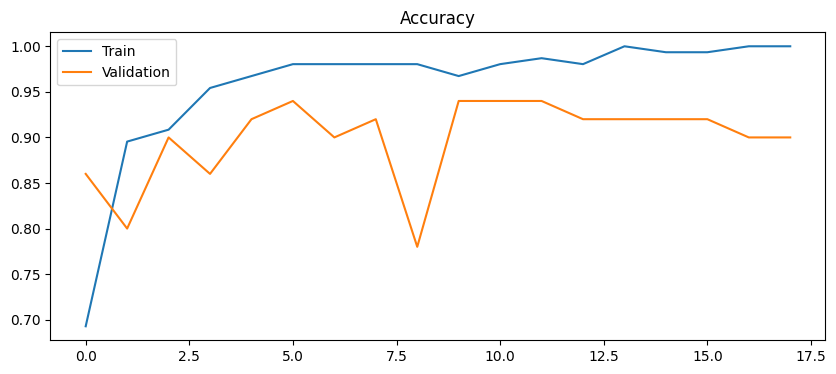

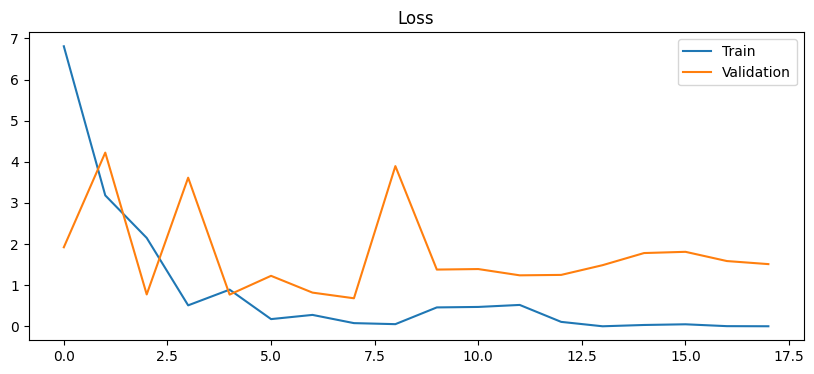

In [36]:

plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Validation"])
plt.title("Loss")
plt.show()


## Test Metrics

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predicciones del modelo
probs = model.predict(test_ds)

# Convertir probabilidades a clases binarias
y_pred = (probs > 0.5).astype(int).flatten()

# Etiquetas reales
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
]).astype(int)

# Métricas
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))

print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["no", "yes"]
    )
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step
Accuracy : 0.86
Precision: 0.875
Recall   : 0.9032258064516129
F1 Score : 0.8888888888888888

Classification Report
              precision    recall  f1-score   support

          no       0.83      0.79      0.81        19
         yes       0.88      0.90      0.89        31

    accuracy                           0.86        50
   macro avg       0.85      0.85      0.85        50
weighted avg       0.86      0.86      0.86        50



## Confusion Matrix

|               | Predicho Negativo | Predicho Positivo |
| ------------- | ----------------- | ----------------- |
| Real Negativo | VN           | FP            |
| Real Positivo | FN        | VP          |

[[15  4]
 [ 3 28]]


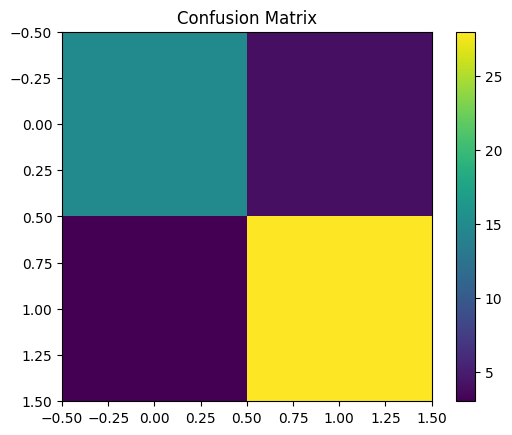

In [38]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

## Save Model

In [40]:

model.save(
    "checkpoints/final/current_matrix_model.keras"
)
print("Model saved.")


Model saved.


## Load Saved Model

In [47]:

loaded_model = load_model(
    "checkpoints/final/current_matrix_model.keras"
)

loaded_model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1000)           │    32,769,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │         1,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,024,693 (431.15 MB)

 Trainable params: 32,770,001 (125.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 65,540,004 (250.02 MB)

## Single Image Inference (loaded model)

In [45]:

from tensorflow.keras.preprocessing import image

img_path = "singles/example_no.png"

img = image.load_img(
    img_path,
    target_size=(256,256)
)

x = image.img_to_array(img)
x = x / 255.0
x = np.expand_dims(x, axis=0)

prob = loaded_model.predict(x)[0][0]

print("Tumor probability:", prob)

if prob > 0.95:
    print("Prediction: YES (Tumor)")
else:
    print("Prediction: NO (Healthy)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Tumor probability: 0.84332556
Prediction: NO (Healthy)
